# Hessian Analysis Visualization

This notebook analyzes and visualizes Hessian matrix properties across different model configurations, creating 2D heatmaps for various Hessian metrics and experimental settings.

Key Hessian metrics analyzed:
- **Trace**: Sum of diagonal elements (overall curvature)
- **Max Eigenvalue**: Largest eigenvalue (sharpest direction)
- **Average Curvature**: Trace normalized by number of parameters
- **Eigenvalue-to-Trace Ratio**: Indicates curvature concentration


## Setup and Configuration


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
c = 'coral'
c1 = 'yellowgreen'
base_c = 'aqua'

plt.rcParams['text.usetex'] = False
sns.set(style="ticks")
plt.rc('font', family='serif')
#plt.rc('font', serif='Times New Roman')

yaxisfont = 32
bigfont   = 20
medfont   = 20
smallfont = 17

plt.rcParams['xtick.labelsize']=medfont
plt.rcParams['ytick.labelsize']=medfont

#sns.set_style('ticks', {'font.family':'serif', 'font.serif':'Times New Roman', 'font.size': 16})
sns.set_palette("muted")

ticks_fontsize = 18
label_fontsize = 20
cbar_fontsize = 18

import matplotlib.font_manager

def generate_plots(x_label_list, y_label_list, data, vmin, vmax, title, ylabel, xlabel, save_path, cmap='Blues'):
    fig, ax = plt.subplots(figsize=(len(x_label_list) * 0.5, len(y_label_list) * 0.5))
    
    # Calculate extent based on data dimensions
    x_extent = [0.5, len(x_label_list) + 0.5]
    y_extent = [len(y_label_list) + 0.5, 0.5]
    
    # Use imshow with adjusted extent
    pos = ax.imshow(
        data,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        aspect='equal',
        origin='upper',
        extent=[x_extent[0], x_extent[1], y_extent[1], y_extent[0]]
    )
    
    plt.title(title, y=1.01, fontsize=bigfont)
    plt.xlabel(xlabel, fontsize=medfont)
    plt.ylabel(ylabel, fontsize=medfont)
    
    # Set ticks to match the center of each cell
    plt.yticks(
        range(1, len(y_label_list) + 1),
        y_label_list,
        fontsize=ticks_fontsize
    )
    plt.xticks(
        range(1, len(x_label_list) + 1),
        [int(item) for item in x_label_list],
        fontsize=ticks_fontsize
    )
    
    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.15)
    cbar = plt.colorbar(pos, cax=cax)
    cbar.ax.tick_params(labelsize=cbar_fontsize)
    
    # Save the figure
    plt.savefig(save_path, dpi=300, bbox_inches='tight')



def min_normalize(matrix, axis=1, topk=1):
    #print(matrix.shape)
    matrix_norm = matrix.copy()
    min_v = np.nanmin(matrix, axis=axis, keepdims=True)
    max_v = np.nanmax(matrix, axis=axis, keepdims=True)

    range_v = max_v - min_v
    range_v[range_v == 0] = 1  # 避免除以零
    
    # 归一化
    matrix_norm = (matrix - min_v) / range_v
    
    return matrix_norm

In [26]:
# Configuration parameters
k_ranges = [[1.0, 2.5], [2.5, 5.0], [5.0, 10.0], [10.0, 20.0], [20.0, 30.0], [30.0, 50.0], [50.0, 100.0], [100.0, 200.0]]
lr_range = [0.001] 
sub_sampling_range = [ 256, 128, 64, 32, 16, 8, 4, 2, 1]  ##4096, 2048, 1024, 512,

# Calculate actual data numbers based on subsample ratio
# Total data amount is 32768, subsample ratio determines how much is used
total_data = 32768
data_number_range = [str(total_data // subsample) for subsample in sub_sampling_range]

seed_range = [2021, 2022, 2023, 2024] ###2025

# Base directory for Hessian results
base_hessian_dir = './hessian_analysis/has_bug_epochnum/hessian_pyhessian'

# Hessian metrics to analyze
hessian_metrics = ['eigenval_max']  #'trace', 'eigenval_max', 'avg_curvature', 'eigenval_to_trace_ratio']

print(f"Configuration loaded:")
print(f"  K ranges: {len(k_ranges)} settings")
print(f"  Subsample ranges: {len(sub_sampling_range)} settings")
print(f"  Actual data numbers: {data_number_range}")
print(f"  Seeds: {len(seed_range)} seeds")
print(f"  Hessian metrics: {hessian_metrics}")


Configuration loaded:
  K ranges: 8 settings
  Subsample ranges: 9 settings
  Actual data numbers: ['128', '256', '512', '1024', '2048', '4096', '8192', '16384', '32768']
  Seeds: 4 seeds
  Hessian metrics: ['eigenval_max']


In [27]:
# Create k_range labels for visualization
k_range_list = []
for k_range in k_ranges:
    if k_range[0]>=10.0:
        k_range_list.append(f'{int(k_range[0])}-')
    else:
        k_range_list.append(f'{k_range[0]}-')

print(f"K-range labels: {k_range_list}")


K-range labels: ['1.0-', '2.5-', '5.0-', '10-', '20-', '30-', '50-', '100-']


## Data Loading Functions


In [28]:
def parse_hessian_file(file_path):
    """
    Parse Hessian result file and extract metrics.
    
    Expected format:
    trace: 43992.72363281
    avg_curvature: 0.04188503
    eigenval_max: 47161.54687500
    sharpness_trace: 43992.72363281
    sharpness_eigenval: 47161.54687500
    eigenval_to_trace_ratio: 1.07203062
    """
    results = {}
    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                line = line.strip()
                if ':' in line and not line.startswith('=') and not line.startswith('-'):
                    key, value = line.split(':', 1)
                    key = key.strip()
                    value = value.strip()
                    
                    # Convert to appropriate types
                    if key in ['eigenval_max']:    #['trace', 'avg_curvature', 'eigenval_max', 'sharpness_trace', 'sharpness_eigenval', 'eigenval_to_trace_ratio']:
                        try:
                            results[key] = float(value)
                        except ValueError:
                            results[key] = value
                    elif key in ['Model parameters']:
                        # Handle comma-separated numbers
                        try:
                            results[key] = int(value.replace(',', ''))
                        except ValueError:
                            results[key] = value
                    elif key in ['Computation time']:
                        try:
                            # Extract numeric value from "XX.XX seconds"
                            results[key] = float(value.split()[0])
                        except (ValueError, IndexError):
                            results[key] = value
                    elif key in ['Checkpoint epoch', 'Batches processed']:
                        try:
                            results[key] = int(value)
                        except ValueError:
                            results[key] = value
                    else:
                        results[key] = value
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None
    
    return results


In [29]:
def get_batch_size_for_subsample(subsamples):
    """Get the appropriate batch size for given subsample value."""
    if subsamples == 512:
        return 64
    elif subsamples == 1024:
        return 32
    elif subsamples == 2048:
        return 16
    elif subsamples == 4096:
        return 8
    else:
        return 128  # default batch size

def get_experiment_epochs(subsamples):
    """Get the experiment epochs based on subsample value."""
    if subsamples in [4096, 2048, 1024, 512, 256]:
        return 1000
    elif subsamples == 128:
        return 750
    elif subsamples == 64:
        return 500
    elif subsamples == 32:
        return 300
    elif subsamples == 16:
        return 200
    elif subsamples == 8:
        return 150
    elif subsamples == 4:
        return 100
    elif subsamples == 2:
        return 75
    elif subsamples == 1:
        return 50
    else:
        return 1000  # default

# Updated function to handle new directory structure
def construct_hessian_file_path(base_dir, k_range, subsample, seed, lr=0.001, method='pyhessian_eigenvalues'):
    """Construct the path to Hessian result file with new directory structure."""
    # Construct PDE setting name
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    
    # Use fixed epochs for the new structure
    epochs = get_experiment_epochs(subsample)
    bsz = get_batch_size_for_subsample(subsample)
    
    # Construct path components
    hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
    seed_setting = f'seed{seed}'
    result_file = f'hessian_{method}_results.txt'
    
    # Full path with new subdirectory structure
    file_path = os.path.join(
        base_dir,
        f'expts_eps{epochs}',
        pde_setting,
        f'hessian_analysis_{method}',
        hyper_setting,
        seed_setting,
        result_file
    )
    
    return file_path

# Update the default method for data loading
default_method = 'pyhessian_eigenvalues'
print("Updated path construction function for new directory structure")


Updated path construction function for new directory structure


## Visualization Functions


In [30]:
# IMPROVED: Load ALL aggregation statistics at once
# This replaces the original load_hessian_statistics function to calculate mean, std, min, max together

def load_all_aggregation_statistics(metric='eigenval_max', method='pyhessian_eigenvalues'):
    """
    Load ALL Hessian aggregation statistics (mean, std, min, max) at once.
    
    Args:
        metric: 'eigenval_max', 'trace', 'avg_curvature', 'eigenval_to_trace_ratio'
        method: 'pyhessian_eigenvalues', 'sharpness', etc.
    
    Returns:
        Dictionary with ALL aggregation statistics organized by configuration
    """
    hessian_stats = {}
    
    print(f"Processing {len(seed_range)} seeds: {seed_range}")
    print(f"Processing {len(sub_sampling_range)} subsampling ranges: {sub_sampling_range}")
    print(f"Processing {len(lr_range)} learning rates: {lr_range}")
    print(f"Processing method: {method}")
    print(f"Processing metric: {metric}")
    
    for k_range in k_ranges:
        pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
        hessian_stats[pde_setting] = {}
        
        for subsample in sub_sampling_range:
            bsz = get_batch_size_for_subsample(subsample)
            lr = lr_range[0]
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
            
            metric_values_by_seed = []
            
            # Load results for all seeds
            for seed in seed_range:
                file_path = construct_hessian_file_path(
                    base_hessian_dir, k_range, subsample, seed, lr, method
                )
                
                if os.path.exists(file_path):
                    result = parse_hessian_file(file_path)
                    if result and metric in result:
                        metric_values_by_seed.append(result[metric])
            
            # Calculate ALL aggregation statistics at once
            if metric_values_by_seed:
                hessian_stats[pde_setting][hyper_setting] = {
                    f'{metric}_mean': np.mean(metric_values_by_seed),
                    f'{metric}_std': np.std(metric_values_by_seed),
                    f'{metric}_min': np.min(metric_values_by_seed),
                    f'{metric}_max': np.max(metric_values_by_seed),
                    f'{metric}_median': np.median(metric_values_by_seed),
                    'num_seeds': len(metric_values_by_seed),
                    'all_values': metric_values_by_seed
                }
            else:
                # No data found
                hessian_stats[pde_setting][hyper_setting] = {
                    f'{metric}_mean': np.nan,
                    f'{metric}_std': np.nan,
                    f'{metric}_min': np.nan,
                    f'{metric}_max': np.nan,
                    f'{metric}_median': np.nan,
                    'num_seeds': 0,
                    'all_values': []
                }
    
    return hessian_stats

# Load ALL aggregation statistics at once
print("Loading ALL Eigenvalue Max statistics (mean, std, min, max) at once...")
all_stats = load_all_aggregation_statistics(metric='eigenval_max', method='pyhessian_eigenvalues')

print("\\nData loading completed! Available aggregations: 'mean', 'std', 'min', 'max', 'median'")
print("Now you can visualize any aggregation without reloading data:")


Loading ALL Eigenvalue Max statistics (mean, std, min, max) at once...
Processing 4 seeds: [2021, 2022, 2023, 2024]
Processing 9 subsampling ranges: [256, 128, 64, 32, 16, 8, 4, 2, 1]
Processing 1 learning rates: [0.001]
Processing method: pyhessian_eigenvalues
Processing metric: eigenval_max


\nData loading completed! Available aggregations: 'mean', 'std', 'min', 'max', 'median'
Now you can visualize any aggregation without reloading data:


In [31]:
def create_hessian_heatmap(hessian_stats, metric, aggregation='mean', figsize=(10, 8), 
                          save_path=None, use_log_scale=False):
    """
    Create a 2D heatmap of Hessian metric values.
    
    Args:
        hessian_stats: Dictionary with Hessian statistics
        metric: 'trace', 'eigenval_max', 'avg_curvature', 'eigenval_to_trace_ratio'
        aggregation: 'mean', 'std', etc. for title and data access
        figsize: Figure size tuple
        save_path: Optional path to save the figure
        use_log_scale: Whether to use log scale for the metric
    """
    # Initialize the heatmap matrix
    hessian_matrix = np.full((len(sub_sampling_range), len(k_ranges)), np.nan)
    
    # Fill the matrix
    for i, subsample in enumerate(sub_sampling_range):
        for j, k_range in enumerate(k_ranges):
            pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
            bsz = get_batch_size_for_subsample(subsample)
            lr = lr_range[0]
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsample}'
            
            if (pde_setting in hessian_stats and 
                hyper_setting in hessian_stats[pde_setting] and
                f'{metric}_{aggregation}' in hessian_stats[pde_setting][hyper_setting]):
                value = hessian_stats[pde_setting][hyper_setting][f'{metric}_{aggregation}']
                if use_log_scale and value > 0:
                    hessian_matrix[i, j] = np.log10(value)
                else:
                    hessian_matrix[i, j] = value
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Choose colormap based on metric
    if metric in ['trace', 'eigenval_max']:
        # Higher values indicate sharper loss landscape (potentially worse)
        cmap = 'viridis_r'
    elif metric == 'avg_curvature':
        # Average curvature - higher can be good or bad depending on context
        cmap = 'viridis'
    elif metric == 'eigenval_to_trace_ratio':
        # Ratio close to 1 means eigenvalues are similar, higher means more concentrated
        cmap = 'RdYlBu_r'
    else:
        cmap = 'viridis'
    
    im = plt.imshow(hessian_matrix, aspect='auto', cmap=cmap, origin='lower')
    
    # Add colorbar
    cbar = plt.colorbar(im)
    label_suffix = f" (Log₁₀)" if use_log_scale else ""
    cbar.set_label(f"{metric.replace('_', ' ').title()} ({aggregation.capitalize()}){label_suffix}", 
                   fontsize=medfont)
    
    # Set ticks and labels
    plt.xticks(ticks=np.arange(len(k_range_list)), labels=k_range_list, fontsize=medfont)
    plt.yticks(ticks=np.arange(len(sub_sampling_range)), labels=data_number_range, fontsize=medfont)
    
    # Set labels and title
    plt.xlabel("PDE Settings (K-range)", fontsize=medfont)
    plt.ylabel("Number of Training Samples", fontsize=medfont)
    title = f"Hessian {metric.replace('_', ' ').title()} - {aggregation.capitalize()}"
    if use_log_scale:
        title += " (Log Scale)"
    plt.title(title, fontsize=yaxisfont)
    
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Heatmap saved to: {save_path}")
    
    plt.show()
    
    return im, hessian_matrix

def print_hessian_statistics(hessian_stats, metric):
    """Print summary statistics of Hessian metric values."""
    all_values = []
    missing_count = 0
    total_count = 0
    
    for pde_setting in hessian_stats:
        for hyper_setting in hessian_stats[pde_setting]:
            total_count += 1
            values = hessian_stats[pde_setting][hyper_setting].get('all_values', [])
            if values:
                all_values.extend(values)
            else:
                missing_count += 1
    
    if all_values:
        print(f"\n{metric.replace('_', ' ').title()} Statistics:")
        print(f"  Total configurations: {total_count}")
        print(f"  Missing data: {missing_count}")
        print(f"  Available values: {len(all_values)}")
        print(f"  Mean: {np.mean(all_values):.4f}")
        print(f"  Std: {np.std(all_values):.4f}")
        print(f"  Min: {np.min(all_values):.4f}")
        print(f"  Max: {np.max(all_values):.4f}")
        print(f"  Median: {np.median(all_values):.4f}")
        
        # Metric-specific interpretations
        if metric == 'trace':
            print(f"  Range: {np.max(all_values) - np.min(all_values):.4f}")
        elif metric == 'eigenval_max':
            print(f"  Range: {np.max(all_values) - np.min(all_values):.4f}")
        elif metric == 'eigenval_to_trace_ratio':
            high_concentration = sum(1 for val in all_values if val > 2.0)
            print(f"  High eigenvalue concentration (>2.0): {high_concentration}/{len(all_values)} ({100*high_concentration/len(all_values):.1f}%)")
    else:
        print(f"No {metric} values found!")


# Maximum Eig

Now you can easily switch between different aggregations:
Available aggregations: 'mean', 'std', 'min', 'max', 'median'

Examples (uncomment to run after defining create_hessian_heatmap):
# create_hessian_heatmap(all_stats, 'eigenval_max', aggregation='mean', figsize=(12, 8))
# create_hessian_heatmap(all_stats, 'eigenval_max', aggregation='std', figsize=(12, 8))
# create_hessian_heatmap(all_stats, 'eigenval_max', aggregation='min', figsize=(12, 8))
# create_hessian_heatmap(all_stats, 'eigenval_max', aggregation='max', figsize=(12, 8))


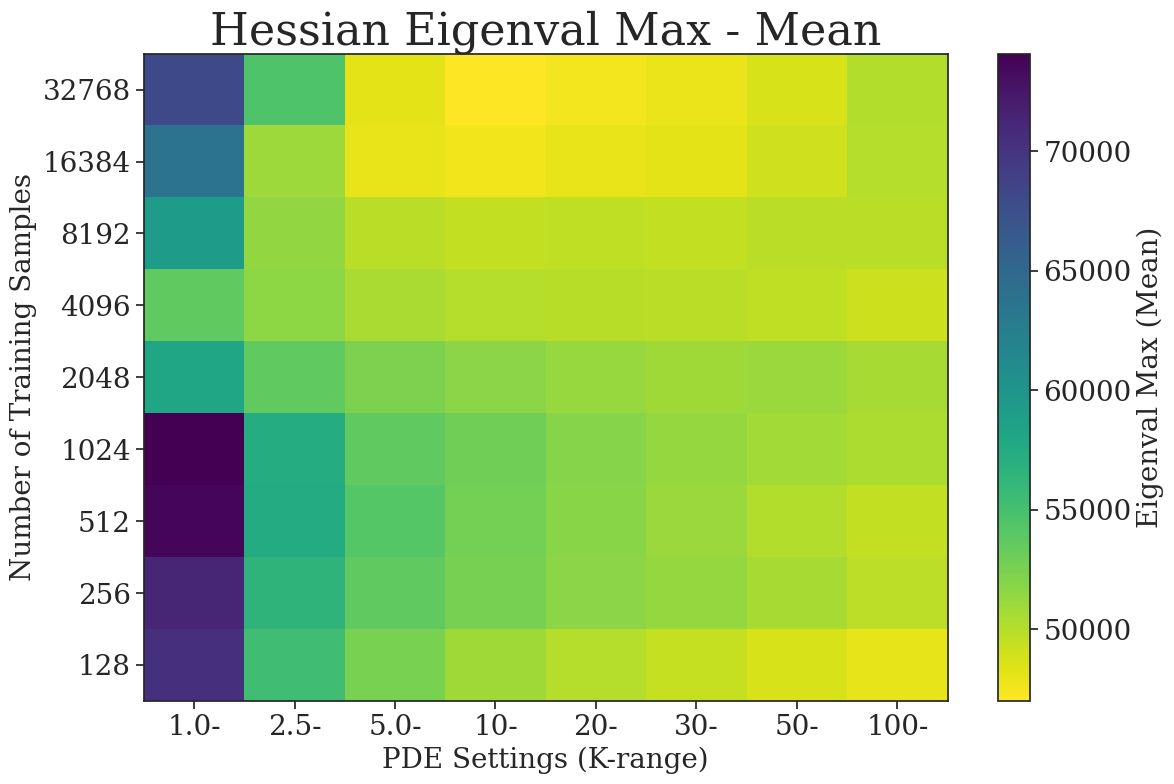

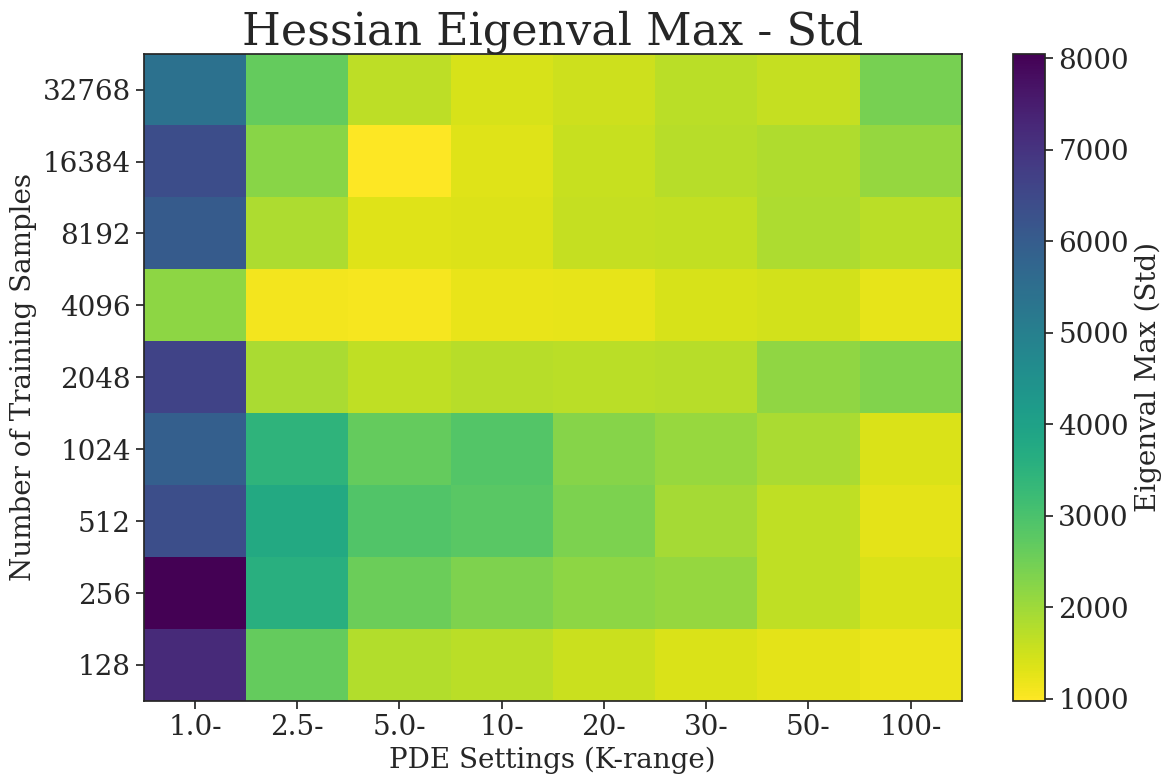

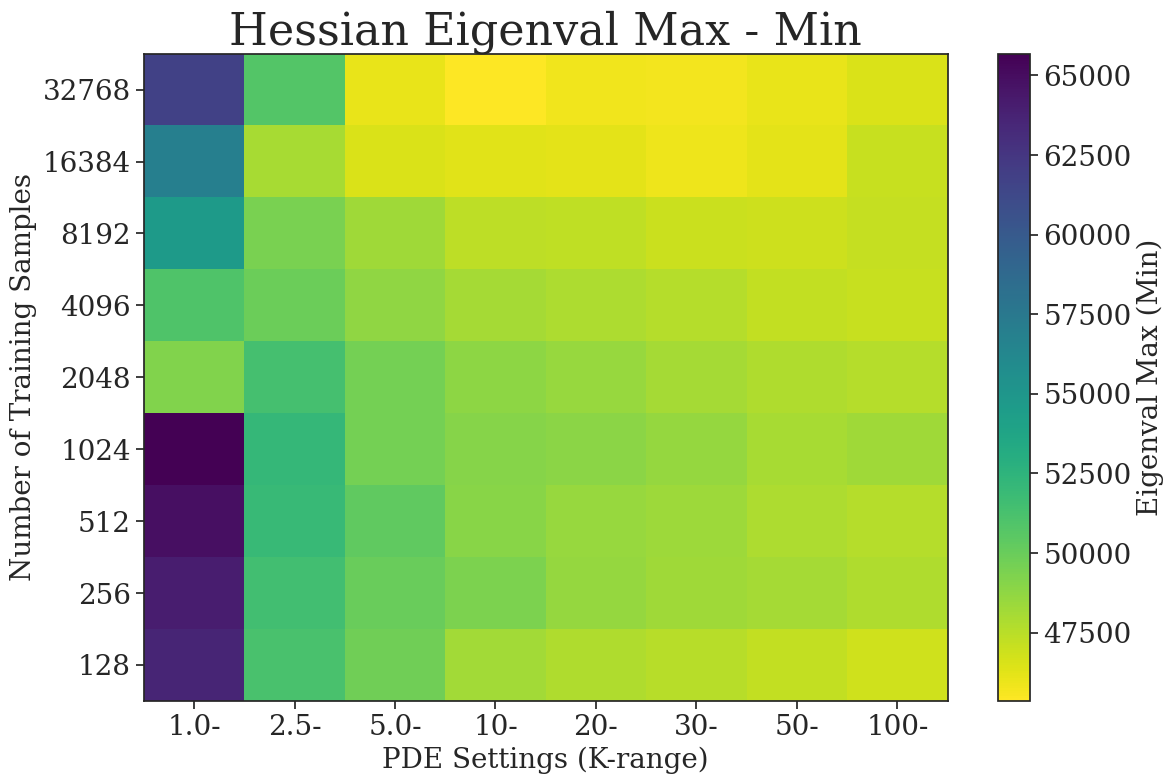

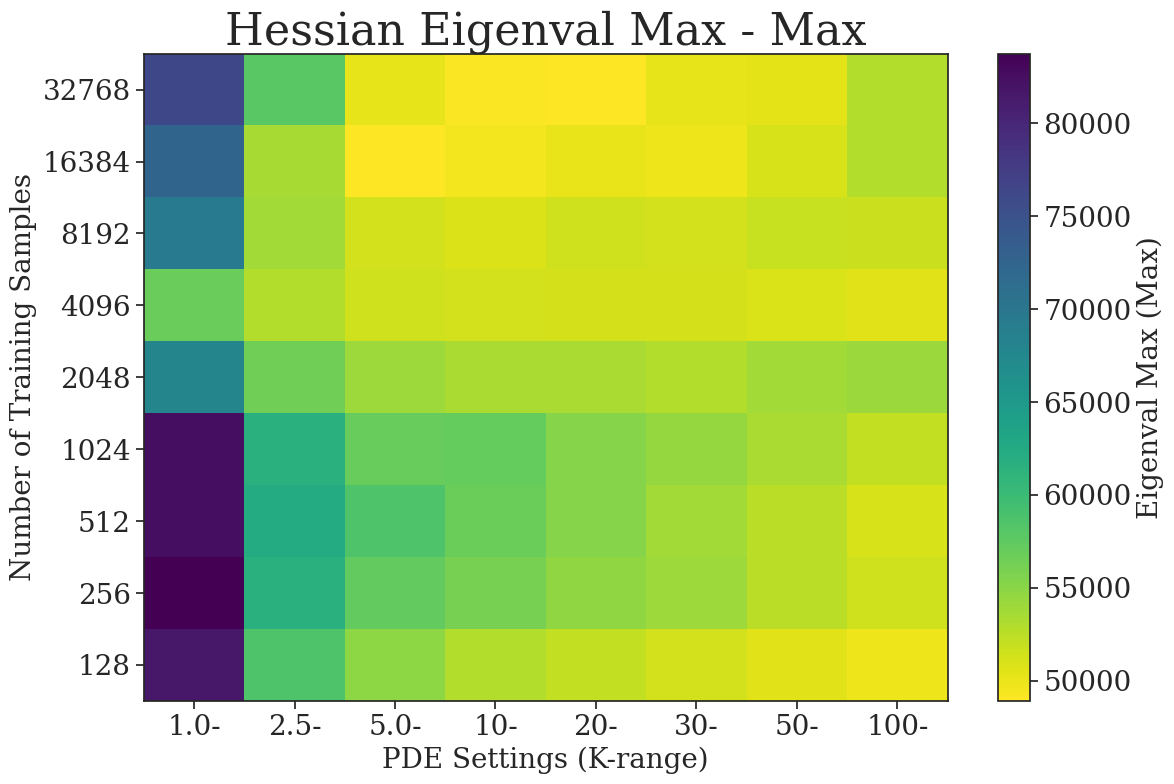

(<matplotlib.image.AxesImage at 0x7958793af610>,
 array([[81570.203125  , 58575.3046875 , 54816.9375    , 52963.453125  ,
         52090.8828125 , 51313.69140625, 50440.21875   , 49770.2265625 ],
        [83749.84375   , 61624.5625    , 57270.8671875 , 56015.015625  ,
         54755.75      , 54081.90234375, 52570.59765625, 51486.953125  ],
        [82486.234375  , 62282.96875   , 58477.7421875 , 56799.0625    ,
         55191.65625   , 53810.7890625 , 52521.1796875 , 51019.3046875 ],
        [82420.8828125 , 61666.3046875 , 57021.3671875 , 57108.7890625 ,
         55216.4765625 , 54360.58203125, 53384.18359375, 52056.99609375],
        [67931.296875  , 56459.47265625, 54001.453125  , 53352.0703125 ,
         53332.578125  , 52924.05078125, 53815.9140625 , 54112.25      ],
        [56926.8671875 , 52951.7265625 , 51440.25      , 51296.4609375 ,
         51194.5703125 , 51106.76171875, 50831.1875    , 50503.8125    ],
        [69492.9765625 , 53750.4375    , 51291.1796875 , 50781.46875 

In [32]:
# Example usage: Visualize different aggregations without reloading data
# Note: Run the visualization function cells below first, then come back to run these examples

print("Now you can easily switch between different aggregations:")
print("Available aggregations: 'mean', 'std', 'min', 'max', 'median'")
print()
print("Examples (uncomment to run after defining create_hessian_heatmap):")
print("# create_hessian_heatmap(all_stats, 'eigenval_max', aggregation='mean', figsize=(12, 8))")
print("# create_hessian_heatmap(all_stats, 'eigenval_max', aggregation='std', figsize=(12, 8))")
print("# create_hessian_heatmap(all_stats, 'eigenval_max', aggregation='min', figsize=(12, 8))")
print("# create_hessian_heatmap(all_stats, 'eigenval_max', aggregation='max', figsize=(12, 8))")

# Uncomment any of these lines to visualize different aggregations:

# Example 1: Visualize MEAN values
create_hessian_heatmap(all_stats, 'eigenval_max', aggregation='mean', figsize=(12, 8))

# Example 2: Visualize STD values
create_hessian_heatmap(all_stats, 'eigenval_max', aggregation='std', figsize=(12, 8))

# Example 3: Visualize MIN values  
create_hessian_heatmap(all_stats, 'eigenval_max', aggregation='min', figsize=(12, 8))

# Example 4: Visualize MAX values
create_hessian_heatmap(all_stats, 'eigenval_max', aggregation='max', figsize=(12, 8))
